In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import netCDF4
from dask import array as da
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import MaxNLocator
from matplotlib.colors import BoundaryNorm
from matplotlib.colors import ListedColormap

import geopandas as gp

import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
from cartopy.util import add_cyclic_point

import glob
from tqdm import tqdm

import re
import cmocean

In [2]:
def setup_axes(ax):
    ax.add_feature(cfeature.LAND, facecolor='lightgrey', zorder=2)
    ax.coastlines(resolution='110m', color='black', lw=2)
    ax.set_ylabel('latitude')
    ax.set_xlabel('longitude')

month_names = {
    1: 'January',
    2: 'February',
    3: 'March',
    4: 'April',
    5: 'May',
    6: 'June',
    7: 'July',
    8: 'August',
    9: 'September',
    10: 'October',
    11: 'November',
    12: 'December'
}

In [3]:
MODE_output = '/glade/work/jtcohen/MODE_files_final/saved_output'
files = [f'{MODE_output}/object_footprints_r3_1989-2003.nc', f'{MODE_output}/object_footprints_r3_2004-2018.nc']
files_random = [f'{MODE_output}/object_footprints_random_1989-2003.nc', f'{MODE_output}/object_footprints_random_2004-2018.nc']
ds = xr.open_mfdataset(files)
ds_random = xr.open_mfdataset(files_random)

In [5]:
%%time
# all_hits = xr.where((ds['fcst_clus_id']>0) | (ds['obs_clus_id']>0), 1, 0).sum(['init', 'member']).load()
fcst_hits = xr.where((ds['fcst_clus_id']>0), 1, 0).sum(['init', 'member']).load()
obs_hits = xr.where((ds['obs_clus_id']>0), 1, 0).sum(['init', 'member']).load()

false_alarms = xr.where(ds['fcst_clus_id']<0, 1, 0).sum(['init', 'member']).load()
misses = xr.where(ds['obs_clus_id']<0, 1, 0).sum(['init', 'member']).load()
new_miss = xr.where(((ds['obs_clus_id']>0) & (np.isnan(ds['fcst_clus_id']))), 1, 0).sum(['init', 'member']).load()  # matched observed object cluster but no overlap with forecast object cluster
correct_negatives = xr.where((np.isnan(ds['fcst_clus_id'])) & (np.isnan(ds['obs_clus_id'])), 1, 0).sum(['init', 'member']).load()

CPU times: user 2min 42s, sys: 2min 44s, total: 5min 26s
Wall time: 9min 48s


In [6]:
obj_hits = fcst_hits
obj_misses = misses + new_miss  # Counts both unmatched forecast object clusters and matched observed object
obj_false_alarms = false_alarms
obj_correct_negatives = correct_negatives

In [7]:
%%time
# all_hits = xr.where((ds['fcst_clus_id']>0) | (ds['obs_clus_id']>0), 1, 0).sum(['init', 'member']).load()
fcst_hits_random = xr.where((ds_random['fcst_clus_id']>0), 1, 0).sum(['init', 'member']).load()
# obs_hits = xr.where((ds['obs_clus_id']>0), 1, 0).sum(['init', 'member']).load()

false_alarms_random = xr.where(ds_random['fcst_clus_id']<0, 1, 0).sum(['init', 'member']).load()
misses_random = xr.where(ds_random['obs_clus_id']<0, 1, 0).sum(['init', 'member']).load()
new_miss_random = xr.where(((ds_random['obs_clus_id']>0) & (np.isnan(ds_random['fcst_clus_id']))), 1, 0).sum(['init', 'member']).load()  # matched observed object cluster but no overlap with forecast object cluster
correct_negatives_random = xr.where((np.isnan(ds_random['fcst_clus_id'])) & (np.isnan(ds_random['obs_clus_id'])), 1, 0).sum(['init', 'member']).load()

CPU times: user 2min 18s, sys: 2min 20s, total: 4min 39s
Wall time: 6min 38s


In [8]:
obj_hits_random = fcst_hits_random
obj_misses_random = misses_random + new_miss_random # Counts both unmatched forecast object clusters and matched observed object
obj_false_alarms_random = false_alarms_random
obj_correct_negatives_random = correct_negatives_random

In [9]:
%%time
# pointwise version
pt_hits = xr.where((~np.isnan(ds['fcst_clus_id'])) & (~np.isnan(ds['obs_clus_id'])), 1, 0).sum(['init', 'member']).load()
pt_misses = xr.where((~np.isnan(ds['fcst_clus_id'])) & (np.isnan(ds['obs_clus_id'])), 1, 0).sum(['init', 'member']).load()
pt_false_alarms = xr.where((np.isnan(ds['fcst_clus_id'])) & (~np.isnan(ds['obs_clus_id'])), 1, 0).sum(['init', 'member']).load()
pt_correct_negatives = correct_negatives

CPU times: user 1min 49s, sys: 1min 53s, total: 3min 42s
Wall time: 4min 17s


In [10]:
objH = obj_hits / (obj_hits + obj_misses)
objF = (obj_false_alarms / (obj_false_alarms + obj_correct_negatives))

obj_sedi = (np.log(objF) - np.log(objH) + np.log(1-objH) - np.log(1-objF)) / \
       (np.log(objF) + np.log(objH) + np.log(1-objH) + np.log(1-objF))

/glade/work/jtcohen/envs/lib/python3.10/site-packages/xarray/core/computation.py:822: RuntimeWarning: divide by zero encountered in log
  result_data = func(*input_data)


In [11]:
ptH = pt_hits / (pt_hits + pt_misses)
ptF = (pt_false_alarms / (pt_false_alarms + pt_correct_negatives))

pt_sedi = (np.log(ptF) - np.log(ptH) + np.log(1-ptH) - np.log(1-ptF)) / \
       (np.log(ptF) + np.log(ptH) + np.log(1-ptH) + np.log(1-ptF))

In [12]:
obj_csi = ((obj_hits) / (obj_hits + obj_misses + obj_false_alarms))
pt_csi = ((pt_hits) / (pt_hits + pt_misses + pt_false_alarms))

In [13]:
obj_FAR = (obj_false_alarms) / (obj_hits + obj_false_alarms)
pt_FAR = (pt_false_alarms) / (pt_hits + pt_false_alarms)

In [14]:
obj_FAR_random = (obj_false_alarms_random) / (obj_hits_random + obj_false_alarms_random)

# Save Fig 2 Data

In [22]:
def calc_det_limit(csi):
    data = xr.where(csi>0.5, 1, 0)
    data.loc[dict(lead=23)] = 0
    data = data.argmin('lead')
    return data

In [23]:
fig2abcd_data = obj_FAR
fig2abcd_data_random = obj_FAR_random
fig2e_data = calc_det_limit(pt_csi)
fig2f_data = calc_det_limit(obj_csi)

In [24]:
data_fold = '/glade/u/home/jtcohen/MODE/notebooks/GRL_code/final_data'
fig2abcd_data.to_netcdf(f'{data_fold}/fig_2abcd.nc')
fig2abcd_data_random.to_netcdf(f'{data_fold}/fig_2abcd_random.nc')
fig2e_data.to_netcdf(f'{data_fold}/fig_2e.nc')
fig2f_data.to_netcdf(f'{data_fold}/fig_2f.nc')

In [58]:
# pt_FAR.to_netcdf(f'{data_fold}/pointwise_FAR.nc')

# Fig 3 Data

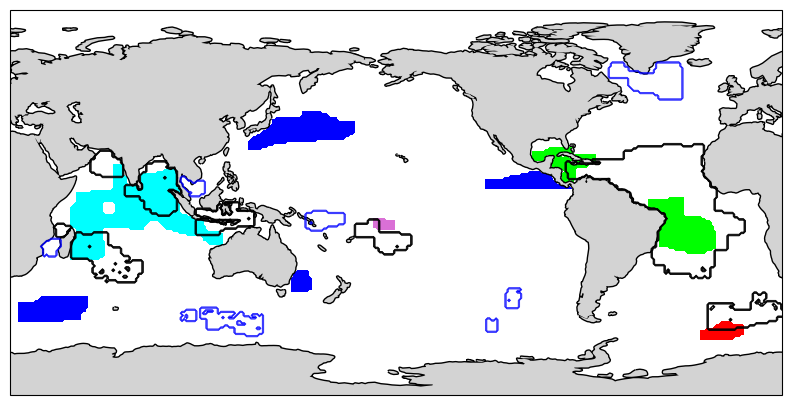

In [23]:
ds_ex = ds.isel(lead=3, member=0, init=84)
fig, ax = plt.subplots(1, 1, figsize=(10, 5), subplot_kw={'projection': ccrs.PlateCarree(200)})
setup_axes(ax)
# data0 = xr.where(ds_ex['fcst_clus_id']>0, ds_ex['fcst_clus_id'], np.nan)
# data1 = xr.where(ds_ex['fcst_clus_id']<0, True, np.nan)
# data2 = xr.where(ds_ex['obs_clus_id']>0, True, False)
# data3 = xr.where(ds_ex['obs_clus_id']<0, True, False)

data0 = xr.where(ds_ex['fcst_clus_id']>0, ds_ex['fcst_clus_id'], np.nan)
data1 = xr.where(ds_ex['fcst_clus_id']<0, True, np.nan)
data2 = xr.where(ds_ex['obs_clus_id']>0, True, False)
data3 = xr.where(ds_ex['obs_clus_id']<0, True, False)

CMap = ListedColormap(['lime', 'orchid', 'cyan', 'red'])
CMap2 = ListedColormap(['None','lime', 'cyan', 'red', 'None'])
CMap2.set_under('None')
CMapbad = ListedColormap(['blue'], N=10)

im0 = ax.contourf(data0.lon, data0.lat, data0, transform=ccrs.PlateCarree(), cmap=CMap)
im1 = ax.contourf(data1.lon, data1.lat, data1, transform=ccrs.PlateCarree(), cmap=CMapbad, vmin=0, vmax=1.3)
im2 = ax.contour(data2.lon, data2.lat, data2, 3, transform=ccrs.PlateCarree(), colors='k', linewidths=0.6)
im3 = ax.contour(data3.lon, data3.lat, data3, 3, transform=ccrs.PlateCarree(), colors='blue', linewidths=0.4)
plt.show()

In [25]:
data_fold = '/glade/u/home/jtcohen/MODE/notebooks/GRL_code/final_data'
ds_ex.to_netcdf(f'{data_fold}/fig1ef.nc')

In [1]:
rs = [1, 2, 3, 4, 5, 6, 7]
# fig, axs = plt.subplots(4, 2, figsize=(15, 15), subplot_kw={'projection': ccrs.PlateCarree(200)}, layout='compressed')
ds_list = []

for i in range(7):
    r = rs[i]
#     ax = axs.flatten()[i]
    if r == 3:
        files = [f'{MODE_output}/object_footprints_r3_1989-2003.nc', f'{MODE_output}/object_footprints_r3_2004-2018.nc']
        ds_ex = xr.open_mfdataset(files).isel(lead=3, member=0, init=84)
    else:
        ds_ex = xr.open_dataset(f'{MODE_output}/object_footprints_r{r}_1989-2018.nc').isel(lead=3, member=0, init=84)
    # ds_ex.to_netcdf(f'{data_fold}/example_field_r{r}.nc')
    ds_list.append(ds_ex)
#     setup_axes(ax)
#     data0 = xr.where(ds_ex['fcst_clus_id']>0, ds_ex['fcst_clus_id'], np.nan) # Matched forecast cluster (hit)
#     data1 = xr.where(ds_ex['fcst_clus_id']<0, True, np.nan) # Unmatched forecast cluster (false alarm)
#     data2 = xr.where(ds_ex['obs_clus_id']>0, True, False) # Matched observed cluster
#     data3 = xr.where(ds_ex['obs_clus_id']<0, True, False) # Unmatched observed cluster (miss)

#     union = xr.where((~np.isnan(ds_ex['fcst_clus_id'])|~np.isnan(ds_ex['obs_clus_id'])), 1, 0).sum(['lat', 'lon'])
#     intersection = xr.where((~np.isnan(ds_ex['fcst_clus_id'])&~np.isnan(ds_ex['obs_clus_id'])), 1, 0).sum(['lat', 'lon'])
#     fiou = intersection / union

#     CMap = ListedColormap(['dodgerblue'])#, 'orchid', 'cyan', 'red', 'yellow', 'forestgreen'])
#     CMap2 = ListedColormap(['None','lime', 'cyan', 'red', 'None'])
#     CMap2.set_under('None')
#     CMapbad = ListedColormap(['crimson'], N=10)

#     im0 = ax.contourf(data0.lon, data0.lat, data0, transform=ccrs.PlateCarree(), cmap=CMap)
#     im1 = ax.contourf(data1.lon, data1.lat, data1, transform=ccrs.PlateCarree(), cmap=CMapbad, vmin=0, vmax=1.3)
#     im2 = ax.contour(data2.lon, data2.lat, data2, 3, transform=ccrs.PlateCarree(), colors='dodgerblue', linewidths=0.6)
#     im3 = ax.contour(data3.lon, data3.lat, data3, 3, transform=ccrs.PlateCarree(), colors='crimson', linewidths=0.4)
#     text = ax.text(0.1, 0.8, f'FIOU: {fiou.values*100:.01f}%', transform=ax.transAxes, fontsize=14, verticalalignment='top')
#     ax.set_title(f'Radius = {r}')

# axs.flatten()[-1].remove()
# # plt.tight_layout()
# plt.show()

In [20]:
ds_save = xr.concat(ds_list, dim='radius')
ds_save['radius'] = rs

In [22]:
ds_save.to_netcdf(f'{data_fold}/example_fields.nc')